In [42]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import random
import matplotlib.pyplot as plt
from skimage.util import random_noise
from tensorflow.keras.layers import Layer, Conv2D, Add, ReLU, Concatenate, GlobalAveragePooling2D, Multiply, Input, Lambda,  MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from keras.models import load_model
from tensorflow.keras.saving import register_keras_serializable


In [43]:

def preprocess(sample, img_size):
    """Preprocessa le immagini: ridimensionamento e normalizzazione."""
    image = tf.image.resize(sample['image'], img_size) / 255.0  # Normalizza in [0,1]
    label = sample['label']  # Estrai l'etichetta
    return image, label

def load_dataset(split, img_size=(256,256), batch_size=16):
    """
    Carica il dataset Oxford-IIIT Pet da tfds e applica il preprocessamento.
    Ritorna un dataset in batch.
    split: 'train[:80%]' 'train[80%:]' 'test'
    """

    print(split)
    dataset = tfds.load('oxford_iiit_pet', split=split, as_supervised=False)  # as_supervised=False per mantenere dict
    dataset = dataset.map(lambda sample: preprocess(sample, img_size))  # Preprocessing
    dataset = dataset.shuffle(1024).batch(batch_size).prefetch(tf.data.AUTOTUNE)  # Ottimizza il caricamento
    return dataset



In [44]:
# Parametri
img_size = (112, 112)
batch_size = 64
noise_factor = 0.4
epochs = 50

# Caricamento dataset
train_ds = load_dataset( split='train[:80%]', img_size=img_size, batch_size=batch_size)
valid_ds = load_dataset( split='train[80%:]', img_size=img_size, batch_size=batch_size)
test_ds  = load_dataset( split='test',        img_size=img_size, batch_size=batch_size)

train[:80%]
train[80%:]
test


In [45]:
def add_noise(x, noise_factor=0.1):
    noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=1.0)
    x_noisy = x + noise_factor * noise
    #x_noisy = tf.clip_by_value(x_noisy, 0.0, 0.1)
    return x_noisy

In [46]:
train_ds_noisy = train_ds.map(lambda x, label: (add_noise(x, noise_factor), x))
valid_ds_noisy = train_ds.map(lambda x, label: (add_noise(x, noise_factor), x))


In [47]:
test_ds_noisy = test_ds.map(lambda x, label: add_noise(x, noise_factor))

In [48]:
def plot_side_by_side(x_noisy, x_original, n=10):
    """
    Visualizza n coppie di immagini affiancando l'immagine rumorosa e quella originale per immagini a colori.
    """
    plt.figure(figsize=(20, 4))
    for i in range(n):
        # Immagine rumorosa
        ax = plt.subplot(2, n, i+1)
        plt.imshow(x_noisy[i])
        plt.title("Rumorosa")
        plt.axis('off')

        # Immagine originale
        ax = plt.subplot(2, n, i+1+n)
        plt.imshow(x_original[i])
        plt.title("Originale")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

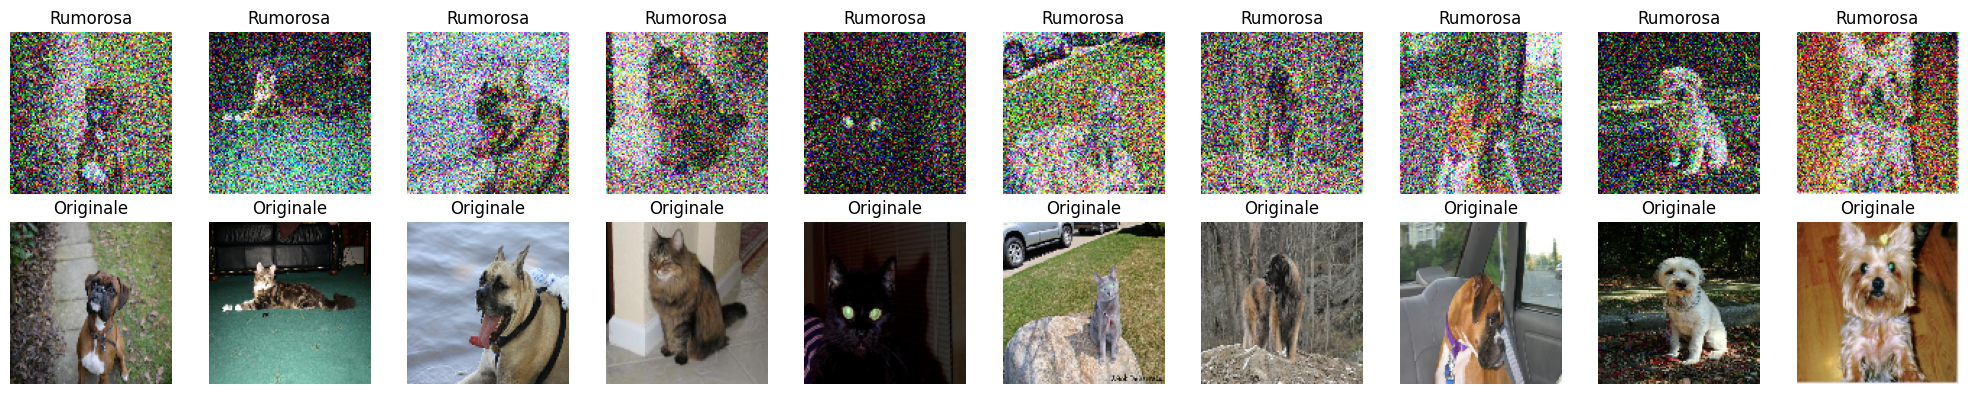

In [49]:
# Prendi un batch dal dataset (ad esempio, il primo batch)
batch = next(iter(train_ds_noisy))
x_noisy_batch, x_original_batch = batch

# Converti i tensori in array NumPy
x_noisy_np = x_noisy_batch.numpy()
x_original_np = x_original_batch.numpy()

# Usa la funzione plot_side_by_side per visualizzare n immagini
plot_side_by_side(x_noisy_np, x_original_np, n=10)


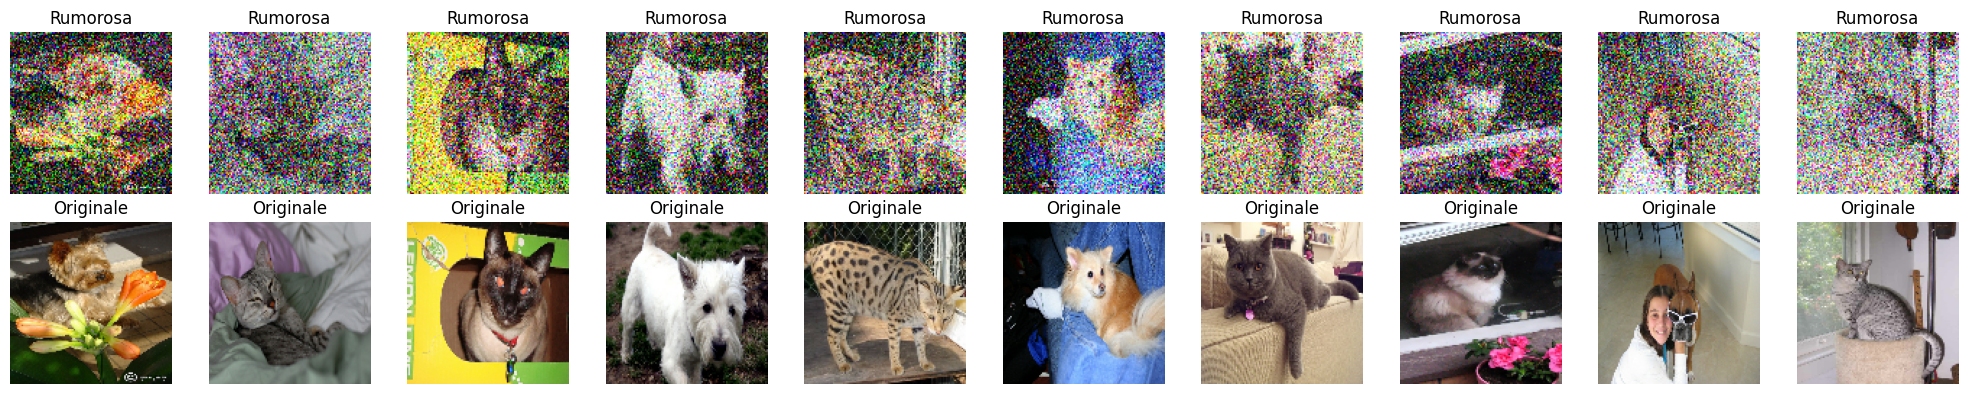

In [50]:
# Prendi un batch dal dataset (ad esempio, il primo batch)
batch = next(iter(valid_ds_noisy))
x_noisy_batch, x_original_batch = batch

# Converti i tensori in array NumPy
x_noisy_np = x_noisy_batch.numpy()
x_original_np = x_original_batch.numpy()

# Usa la funzione plot_side_by_side per visualizzare n immagini
plot_side_by_side(x_noisy_np, x_original_np, n=10)

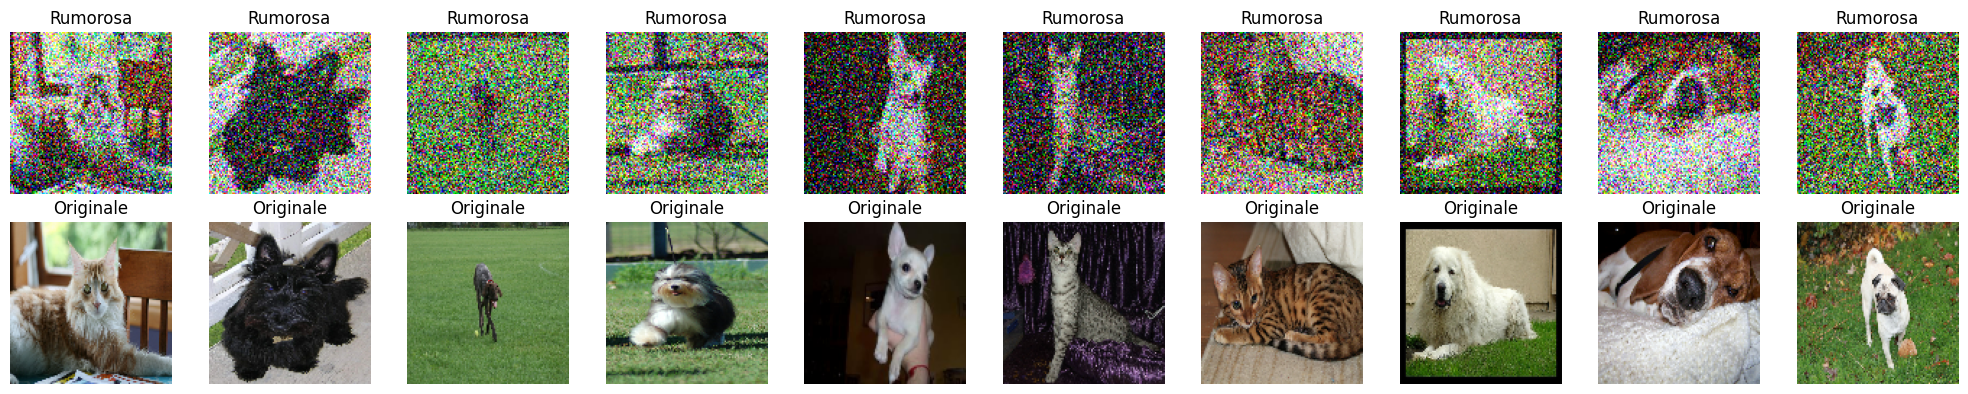

In [51]:
# Prendi un batch dal dataset (ad esempio, il primo batch)
batch = next(iter(valid_ds_noisy))
x_noisy_batch, x_original_batch = batch

# Converti i tensori in array NumPy
x_noisy_np_test = x_noisy_batch.numpy()
x_original_np_test = x_original_batch.numpy()

# Usa la funzione plot_side_by_side per visualizzare n immagini
plot_side_by_side(x_noisy_np_test, x_original_np_test, n=10)

Creazione modello

In [52]:
def plot_denoising_results(x_test_noisy, decoded_imgs, x_test, n=10):
    """
    Visualizza n immagini rumorose, le rispettive immagini denoised e quelle originali.
    """
    plt.figure(figsize=(20, 4))
    n = 10
    for i in range(n):
        # Immagine rumorosa
        ax = plt.subplot(3, n, i + 1)
        plt.imshow(x_test_noisy[i])
        plt.title("Rumorosa")
        plt.axis('off')
        # Immagine denoised
        ax = plt.subplot(3, n, i + 1 + n)
        plt.imshow(decoded_imgs[i])
        plt.title("Denoised")
        plt.axis('off')
        # Immagine originale
        ax = plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(x_test[i])
        plt.title("Originale")
        plt.axis('off')
    plt.tight_layout()
    plt.show()


In [53]:
def psnr(original, denoised):
  mse = np.mean((original - denoised) ** 2)
  if mse == 0:
    return float('inf') # immagini identiche
  max_pixel = 1.0 # valore massimo per immagini normalizzate in [0, 1]
  return 10 * np.log10((max_pixel ** 2) / mse)

In [54]:
def build_autoencoder(input_shape):
    """
    Costruisce un autoencoder convoluzionale per immagini a colori.
    Parametri:
      input_shape: forma dell'immagine in input (es. (32,32,3))
    Ritorna:
      autoencoder: modello compilato
    """
    input_img = Input(shape=input_shape)

    # Encoder
    x = Conv2D(64, (3,3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2,2), padding='same')(x)
    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2,2), padding='same')(x)

    # Decoder
    x = Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
    x = UpSampling2D((2,2))(x)
    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = UpSampling2D((2,2))(x)
    decoded = Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

    autoencoder = Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    return autoencoder

def train_autoencoder(autoencoder, x_train_noisy, x_train, x_test_noisy, x_test, epochs=50, batch_size=128):
    """
    Addestra l'autoencoder utilizzando le immagini rumorose come input e quelle originali come target.
    """
    history = autoencoder.fit(x_train_noisy, x_train,
                              epochs=epochs,
                              batch_size=batch_size,
                              shuffle=True,
                              validation_data=(x_test_noisy, x_test))
    return history

In [55]:
autoencoder = build_autoencoder(input_shape=(img_size[0], img_size[1], 3))
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 112, 112, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 112, 112, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 56, 56, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 3)    │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,307 (446.51 KB)

 Trainable params: 114,307 (446.51 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
history = autoencoder.fit(train_ds_noisy,
                validation_data=valid_ds_noisy,
                batch_size=batch_size,
                epochs=50)

Epoch 1/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 27s 374ms/step - accuracy: 0.5203 - loss: 0.6128 - val_accuracy: 0.6106 - val_loss: 0.5509
Epoch 2/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 17s 324ms/step - accuracy: 0.6060 - loss: 0.5521 - val_accuracy: 0.6319 - val_loss: 0.5468
Epoch 3/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 22s 328ms/step - accuracy: 0.6313 - loss: 0.5467 - val_accuracy: 0.6384 - val_loss: 0.5453
Epoch 4/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 16s 314ms/step - accuracy: 0.6351 - loss: 0.5475 - val_accuracy: 0.6641 - val_loss: 0.5452
Epoch 5/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 19s 378ms/step - accuracy: 0.6656 - loss: 0.5460 - val_accuracy: 0.6568 - val_loss: 0.5429
Epoch 6/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 16s 314ms/step - accuracy: 0.6921 - loss: 0.5432 - val_accuracy: 0.7147 - val_loss: 0.5424
Epoch 7/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 16s 315ms/step - accuracy: 0.7038 - loss: 0.5424 - val_accuracy: 0.7006 - val_loss: 0.5416
Epoch 8/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 17s 312ms/step - accuracy: 0.7110 - loss: 0.5445 - val_accu

Predict e grafici

In [57]:
decoded_imgs = autoencoder.predict(x_noisy_np_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


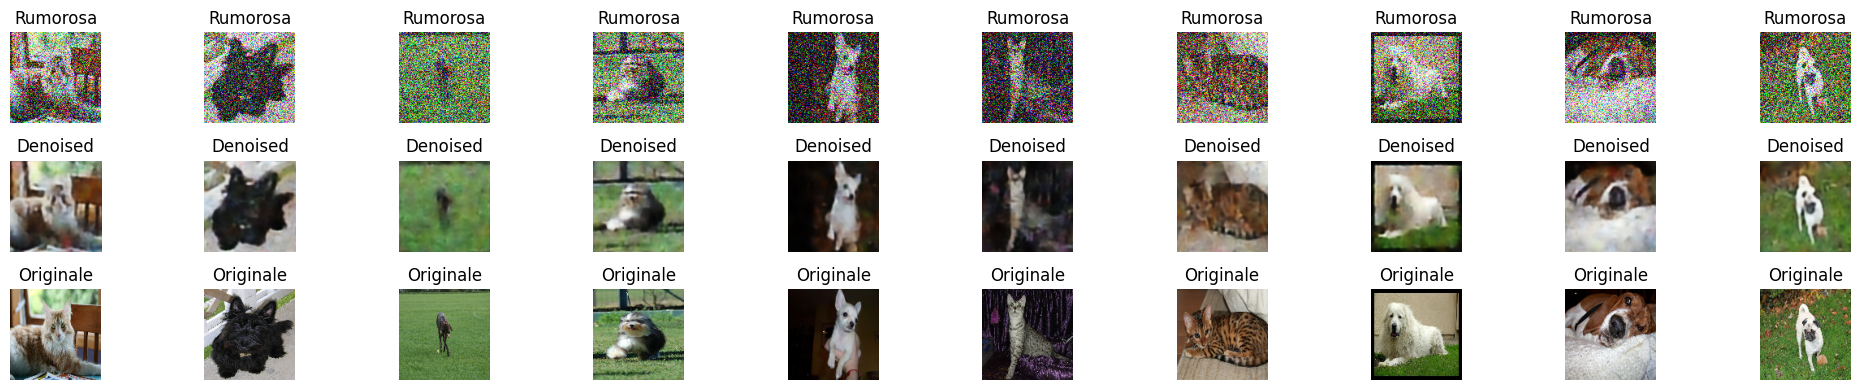

In [58]:
plot_denoising_results(x_noisy_np_test, decoded_imgs, x_original_np_test, n=10)

In [59]:
print(history.history.keys())  # mostra le chiavi disponibili

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [60]:
print(history.history['accuracy'])

[0.5474773049354553, 0.621555507183075, 0.6367170810699463, 0.6433826684951782, 0.6733601093292236, 0.7006887197494507, 0.7083860635757446, 0.7104975581169128, 0.7136957049369812, 0.7154474854469299, 0.7114249467849731, 0.7169309854507446, 0.717953622341156, 0.7181123495101929, 0.7185094356536865, 0.7200363874435425, 0.7196153402328491, 0.7195839881896973, 0.721290111541748, 0.7197206616401672, 0.7214130759239197, 0.7221473455429077, 0.7174290418624878, 0.7218379378318787, 0.7228805422782898, 0.7217394709587097, 0.7220024466514587, 0.721899688243866, 0.72232985496521, 0.7234553694725037, 0.7222656607627869, 0.720359742641449, 0.7234634757041931, 0.7228031754493713, 0.7243150472640991, 0.7247248888015747, 0.7243239283561707, 0.7239695191383362, 0.7243865728378296, 0.7225692868232727, 0.7248530387878418, 0.7246189117431641, 0.723814845085144, 0.725567102432251, 0.7254016995429993, 0.7252107858657837, 0.7262353301048279, 0.7233846187591553, 0.7258188724517822, 0.7251299023628235]


In [61]:
autoencoder.save('new_autoencoder.keras')

In [62]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epochs)

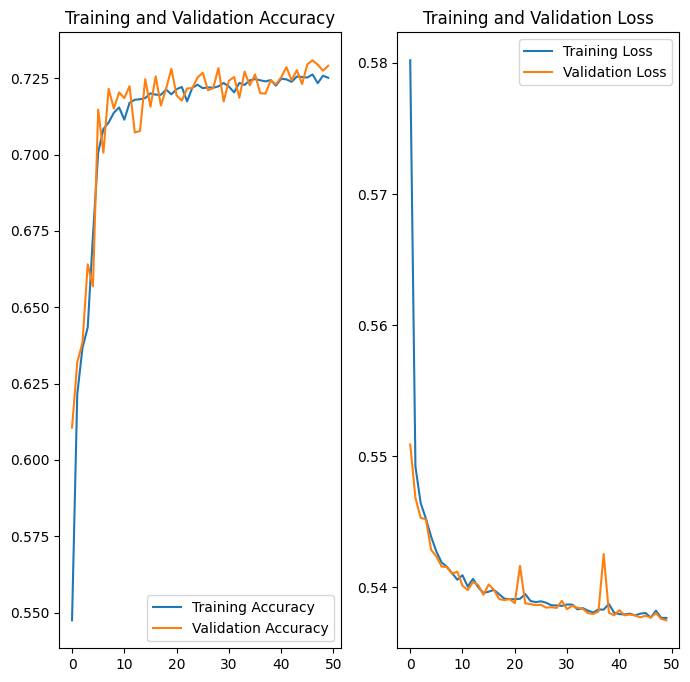

In [63]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [64]:
from skimage.metrics import peak_signal_noise_ratio as psnr

In [67]:
def calculate_psnr(img1, img2):
    """
    Calcola il PSNR tra due immagini TensorFlow (img1 e img2).
    Entrambe devono essere float32 e normalizzate (0-1) o in uint8 (0-255).
    """
    return tf.image.psnr(img1, img2, max_val=1.0 if img1.dtype.is_floating else 255.0).numpy()


In [68]:
from collections import defaultdict

In [69]:
def psnr_by_noise_level(noisy_images, original_images, noise_levels):
    psnr_dict = defaultdict(list)

    for noisy, original, level in zip(noisy_images, original_images, noise_levels):
        psnr = calculate_psnr(tf.convert_to_tensor(noisy), tf.convert_to_tensor(original))
        psnr_dict[level].append(psnr)

    # Calcola media per ogni livello di rumore
    avg_psnr_by_level = {level: np.mean(values) for level, values in psnr_dict.items()}

    return avg_psnr_by_level

In [70]:
def plot_psnr_vs_noise(psnr_dict):
    levels = sorted(psnr_dict.keys())
    psnr_values = [psnr_dict[level] for level in levels]

    plt.figure(figsize=(8, 5))
    plt.plot(levels, psnr_values, marker='o')
    plt.xlabel("Fattore di rumore")
    plt.ylabel("PSNR medio (dB)")
    plt.title("PSNR vs Livello di Rumore")
    plt.grid(True)
    plt.show()

In [75]:
noise_levels = np.linspace(0,1,11)

In [76]:
print(noise_levels)

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


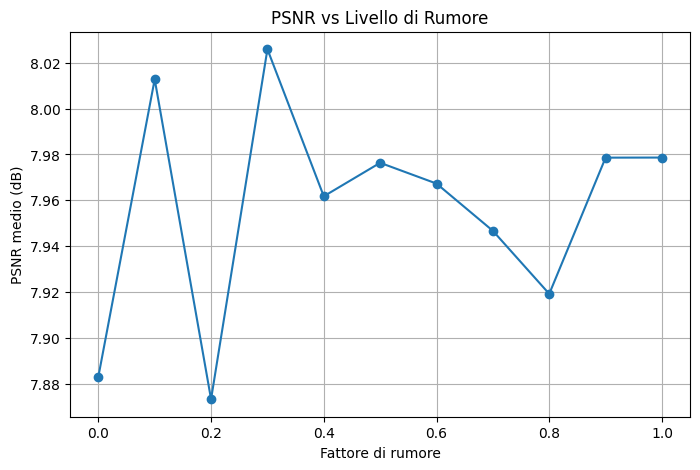

In [77]:
x_noisy_np_test, decoded_imgs, x_original_np_test
avg_psnr = psnr_by_noise_level(x_noisy_np_test, x_original_np_test, noise_levels)
plot_psnr_vs_noise(avg_psnr)


In [78]:
psnr_values = [psnr(x_noisy_np[i], decoded_imgs[i], data_range=1.0) for i in range(len(test_ds_noisy))]


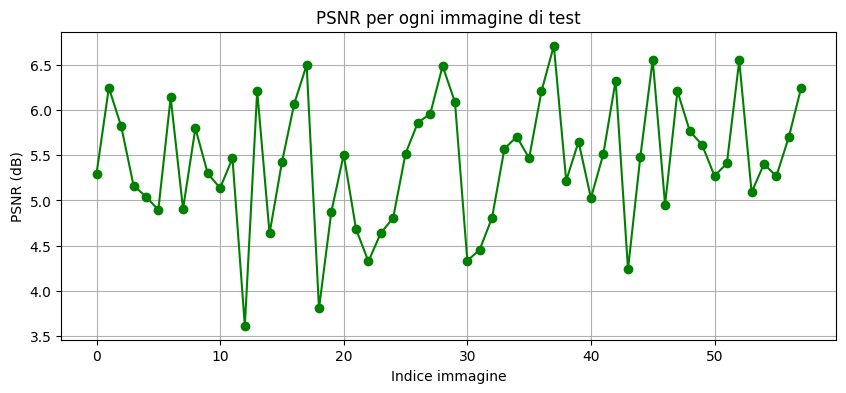

Media PSNR sul test set: 5.43 dB


In [79]:

# Plot dei PSNR per ogni immagine
plt.figure(figsize=(10, 4))
plt.plot(psnr_values, marker='o', linestyle='-', color='green')
plt.title('PSNR per ogni immagine di test')
plt.xlabel('Indice immagine')
plt.ylabel('PSNR (dB)')
plt.grid(True)
plt.show()

# (Facoltativo) Media PSNR
print(f"Media PSNR sul test set: {np.mean(psnr_values):.2f} dB")